In [2]:
import os
import sys
from pathlib import Path

# Проверяем, запускался ли уже этот блок
if "IS_ROOT_SET" not in globals():
    project_root = Path.cwd().parent.parent
    os.chdir(project_root)

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    # Создаем флаг-индикатор
    IS_ROOT_SET = True
    print("Корневая директория инициализирована.")
else:
    print("Инициализация уже была выполнена ранее.")

Корневая директория инициализирована.


Преобразование датасета в формат YOLO

In [3]:
from src.schemas.coco_dataset import COCODataset
from pathlib import Path

dataset_dir = Path("datasets/minecraft")

train_dataset = COCODataset.load(path=dataset_dir / "train")
valid_dataset = COCODataset.load(path=dataset_dir / "valid")
test_dataset = COCODataset.load(path=dataset_dir / "test")

In [34]:
from ultralytics.data.converter import convert_coco
from ultralytics import YOLO
import shutil
import cv2
import matplotlib.pyplot as plt

In [24]:
def convert_dataset_to_yolo_format(base_dir: Path, output_dir: Path) -> None:
    # splits = ["test"]
    if output_dir.exists():
        raise RuntimeError("{output_dir} exists. Delete it")
    splits = ["train", "valid", "test"]
    for split in splits:
        try:
            split_dir = base_dir / split

            yolo_images_dir = output_dir / "images" / split
            yolo_labels_dir = output_dir / "labels" / split
            yolo_images_dir.mkdir(parents=True, exist_ok=True)
            yolo_labels_dir.mkdir(parents=True, exist_ok=True)

            tmp_out = split_dir / "tmp_yolo"

            convert_coco(
                labels_dir=str(split_dir),
                save_dir=str(tmp_out),
                use_segments=False,
                cls91to80=False,
            )
            for file in (tmp_out / "labels" / "annotations").glob("*.txt"):
                shutil.move(str(file), yolo_labels_dir)

            valid_extensions = {
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp",
                ".webp",
                ".JPG",
                ".PNG",
            }
            for image in split_dir.iterdir():
                if image.suffix in valid_extensions:
                    shutil.copy(str(image), str(yolo_images_dir / image.name))
        finally:
            shutil.rmtree(tmp_out)

In [29]:
def create_data_yaml(base_dir: Path, output_dir: Path) -> None:
    classes = {cat.id: cat.name for cat in train_dataset.categories}
    content = f"""path: {output_dir.resolve().as_posix()}

train: images/train
val: images/valid
test: images/test

names:
"""
    for idx, cls_name in classes.items():
        if idx == 0:
            continue
        content += f"\t{idx - 1}: {cls_name}\n"

    data_yaml_path = output_dir / "data.yml"

    with open(data_yaml_path, "w", encoding="utf-8") as f:
        f.write(content)

In [30]:
convert_dataset_to_yolo_format(
    Path("datasets/minecraft"), Path("datasets/yolo_minecraft")
)
create_data_yaml(Path("datasets/minecraft"), Path("datasets/yolo_minecraft"))

Annotations /home/vdavydov/projects/minecraft-object-detection/datasets/minecraft/train/annotations.json: 100% ━━━━━━━━━━━━ 2307/2307 12.5Kit/s 0.2s.3s
COCO data converted successfully.
Results saved to /home/vdavydov/projects/minecraft-object-detection/datasets/minecraft/train/tmp_yolo
Annotations /home/vdavydov/projects/minecraft-object-detection/datasets/minecraft/valid/annotations.json: 100% ━━━━━━━━━━━━ 422/422 18.8Kit/s 0.0s
COCO data converted successfully.
Results saved to /home/vdavydov/projects/minecraft-object-detection/datasets/minecraft/valid/tmp_yolo
Annotations /home/vdavydov/projects/minecraft-object-detection/datasets/minecraft/test/annotations.json: 100% ━━━━━━━━━━━━ 155/155 15.7Kit/s 0.0s
COCO data converted successfully.
Results saved to /home/vdavydov/projects/minecraft-object-detection/datasets/minecraft/test/tmp_yolo


Проверка валидности преобразования

In [32]:
test_image_path = "datasets/yolo_minecraft/images/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg"
output_dir = Path("src/artifacts/inference/yolo_val/")
output_dir.mkdir(parents=True, exist_ok=True)

In [33]:
model = YOLO("yolov8s.pt")

In [42]:
results = model.predict(
    source=test_image_path,
    project=str(output_dir.parent.resolve()),
    save=True,
    exist_ok=True,
    conf=0.01,
)


image 1/1 /home/vdavydov/projects/minecraft-object-detection/datasets/yolo_minecraft/images/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg: 512x640 1 parking meter, 1 toilet, 1 refrigerator, 133.4ms
Speed: 3.6ms preprocess, 133.4ms inference, 16.4ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /home/vdavydov/projects/minecraft-object-detection/src/artifacts/inference/yolo_val


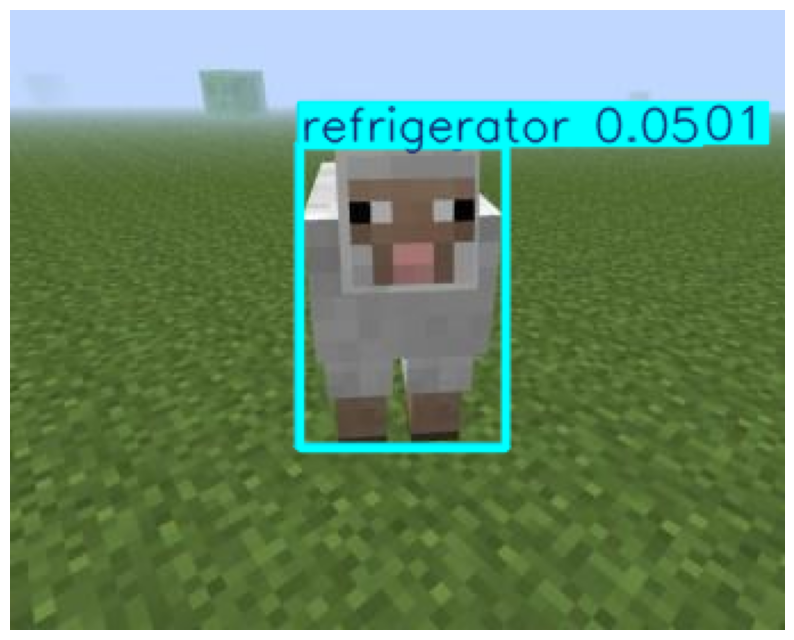

In [43]:
annotated_frame = results[0].plot()

annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_frame_rgb)
plt.axis("off")
plt.show()